In [ ]:
pip install nltk

In [ ]:
pip install seaborn wordcloud

# Twitter Sentiment Analysis – Concept & Dataset Explanation  


### 📌 What is Sentiment Analysis?

**Sentiment Analysis** is a **Natural Language Processing (NLP)** technique used to identify the **emotional tone** expressed in text data.

It automatically classifies text into sentiment categories such as:

- 😊 **Positive**
- 😡 **Negative**
- 😐 **Neutral** *(in some datasets)*



### How It Works

When a user writes a tweet like:

> *“I love this phone, it’s amazing!”*

The sentiment analysis system performs the following steps:

1. **Text Cleaning**  
   - Removes URLs, mentions, symbols, stopwords, etc.
2. **Text Vectorization**  
   - Converts words into numerical features
3. **Model Processing**  
   - Applies a machine learning or deep learning model
4. **Prediction**  
   - Outputs the sentiment → **Positive**



### Real-World Applications

Sentiment Analysis is widely used by companies such as:

- **:contentReference[oaicite:0]{index=0}** – Trend detection & public opinion analysis  
- **:contentReference[oaicite:1]{index=1}** – Product review and rating analysis  
- **:contentReference[oaicite:2]{index=2}** – Social media monitoring and content analysis  

### Common Use Cases
- Brand reputation monitoring  
- Political opinion analysis  
- Automated customer feedback systems  
- Stock market sentiment tracking  
- Crisis and disaster detection  





## 📊 About the Dataset – **Sentiment140**

We use a **real-world Twitter dataset** called **Sentiment140**.

https://www.kaggle.com/datasets/kazanova/sentiment140

### 📁 Dataset Overview

| Feature        | Description              |
|---------------|--------------------------|
| **Total Tweets** | 1.6 Million             |
| **Source**       | Twitter                 |
| **Labels**       | Positive / Negative     |
| **Language**     | English                 |
| **Format**       | CSV                     |


### 📌 Why Is It Called *Sentiment140*?

The name comes from Twitter’s **original 140-character limit**.

- Early tweets were restricted to **140 characters**
- The dataset was collected during that period

### Dataset Columns

The original Sentiment140 dataset contains **6 columns**:

| Column  | Meaning            |
|--------|--------------------|
| target | Sentiment label    |
| id     | Tweet ID           |
| date   | Date of tweet      |
| flag   | Query              |
| user   | Username           |
| text   | Actual tweet text  |

### ✅ Columns Used in Our Project
We only use:

- **target**
- **text**



### Sentiment Labels

| Original Label | Meaning   |
|---------------|-----------|
| 0             | Negative  |
| 4             | Positive  |

###  Label Conversion
We convert:

- **4 → 1**

So the final labels become:

| Final Label | Sentiment |
|------------|-----------|
| 0          | Negative  |
| 1          | Positive  |



## 🚀 Why This Dataset Is Powerful

- 🔢 **Large-scale** → 1.6 million tweets  
- 🌍 **Real-world data** → noisy and unstructured  
- 😄 Contains **slang, hashtags, emojis**  
- ⚙️ **Automatically labeled**  
- 📱 Closely simulates **real social media text**

This makes it **ideal for live demos and practical NLP projects**.

---

### Perfect for:
- Machine Learning demos  
- NLP pipelines  
- Google Colab live training sessions  
- Academic mini-projects  


**STEP 1 — Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

**STEP 2 — Load Dataset**

In [2]:
columns = ['target', 'id', 'date', 'flag', 'user', 'text']

df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=columns,
    engine='python'
)

df = df[['target', 'text']]

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1600000, 2)


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


**STEP 3 — Fix Labels**

In [3]:
df['target'] = df['target'].replace(4, 1)
df['target'].value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

**STEP 4 — Sentiment Distribution Visualization**

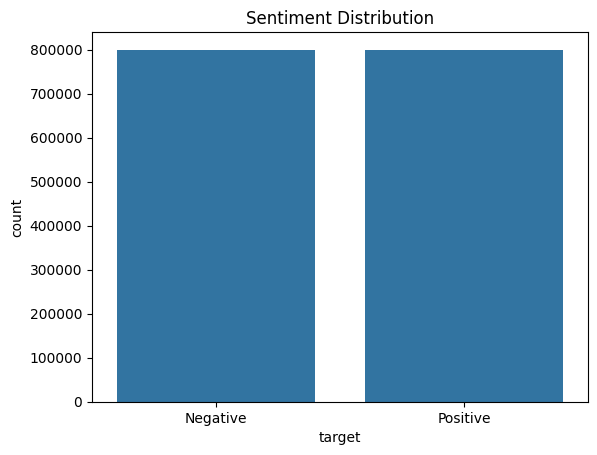

In [4]:
plt.figure()
sns.countplot(x='target', data=df)
plt.xticks([0,1], ['Negative','Positive'])
plt.title("Sentiment Distribution")
plt.show()

**STEP 5 — Clean Tweets**

### Why Text Cleaning Is Important in Twitter Sentiment Analysis?

Tweets are **noisy and unstructured**, meaning they contain many elements that do **not directly contribute to sentiment prediction**.

### Common Noise in Tweets
Tweets often include:

- 🔗 **URLs** (links to external sites)
- 👤 **Mentions** (`@username`)
- #️⃣ **Hashtags**
- 😄 **Emojis**
- 🗣️ **Slang and informal language**
- ✨ **Special characters & punctuation**
- 🔠 **Unnecessary capitalization**


### Why We Remove These?

Most machine learning models **do not understand raw text**.  
They learn patterns from **important words**, not from noise.

Cleaning helps by:
- Removing irrelevant information
- Reducing vocabulary size
- Improving learning efficiency
- Increasing **model accuracy**


## 📝 Example

### ❌ Original Tweet
```text
@john I LOVE this movie!!! 😍🔥 http://xyz.com
```

### ✅ After Cleaning
```text
love movie
```

In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad see


**STEP 6 — WordCloud Visualization**

**Positive Tweets**

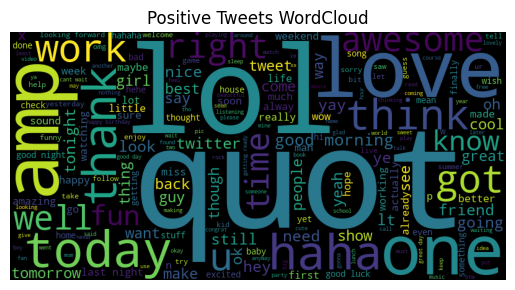

In [ ]:
positive_words = " ".join(df[df['target']==1]['clean_text'])

wordcloud_pos = WordCloud(width=800, height=400).generate(positive_words)

plt.figure()
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title("Positive Tweets WordCloud")
plt.show()

**Negative Tweets**

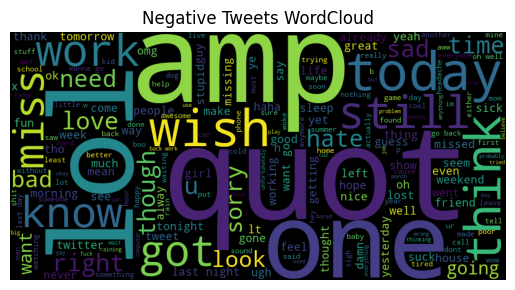

In [ ]:
negative_words = " ".join(df[df['target']==0]['clean_text'])

wordcloud_neg = WordCloud(width=800, height=400).generate(negative_words)

plt.figure()
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title("Negative Tweets WordCloud")
plt.show()

**STEP 7 — Feature Engineering (TF-IDF)**

We use:

- TF-IDF Vectorization

- Logistic Regression

TF-IDF converts text into numerical format.

Logistic Regression learns patterns between words and sentiment.

In [6]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['target']

In [10]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (1600000, 5000)


In [11]:
tweet_index = 0

print("Original Tweet:\n", df.iloc[tweet_index]['text'])

tweet_vector = X[tweet_index].toarray()

feature_names = tfidf.get_feature_names_out()
tweet_df = pd.DataFrame(tweet_vector, columns=feature_names)

# Show only non-zero values
tweet_df.loc[:, (tweet_df != 0).any(axis=0)]


Original Tweet:
 @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


,awww,bummer,david,day,got,shoulda,third
0,0.350865,0.418927,0.396352,0.207885,0.226212,0.496077,0.451462


**STEP 8 — Train Model**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**STEP 9 — Evaluate Model**

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.76844375

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.74      0.76    159494
           1       0.76      0.79      0.77    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



**STEP 10 — Confusion Matrix**

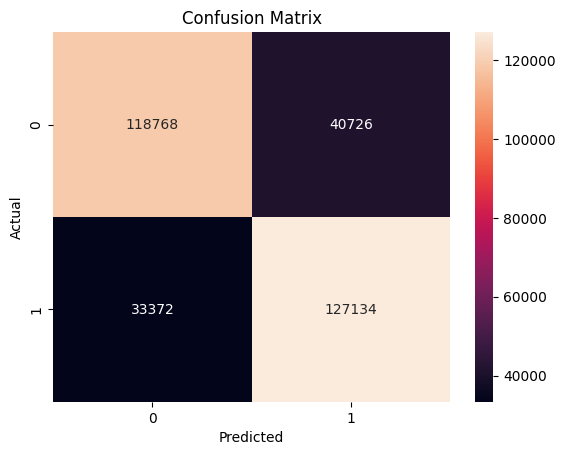

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**STEP 11 — PREDICTION**

In [ ]:
def predict_sentiment(tweet):
    tweet = clean_text(tweet)
    tweet_vec = tfidf.transform([tweet])
    prediction = model.predict(tweet_vec)
    return "Positive 😊" if prediction[0] == 1 else "Negative 😡"

print(predict_sentiment("I love this phone!"))
print(predict_sentiment("This service is horrible and slow"))

Positive 😊
Negative 😡
